In [4]:
# 1️⃣ Import Libraries
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pickle

In [5]:
# 2️⃣ Load Dataset
true_df = pd.read_csv("True.csv")
fake_df = pd.read_csv("Fake.csv")

true_df["label"] = 0  # Real
fake_df["label"] = 1  # Fake

df = pd.concat([true_df, fake_df])
df = df.sample(frac=1).reset_index(drop=True)


In [6]:
df.head()

,title,text,subject,date,label
0,"BOILER ROOM – EP #58 – Lord of the Pedo Rings,...",Tune in to the Alternate Current Radio Network...,Middle-east,"May 26, 2016",1
1,WHY OBAMA’S CORRUPT INNER CIRCLE Is Desperatel...,"History shows that we can, if we must, tolera...",politics,"Dec 23, 2017",1
2,Austria's likely next chancellor hopes to form...,ZURICH (Reuters) - Austria s likely next chanc...,worldnews,"October 22, 2017",0
3,"China's U.N. envoy says North Korea, U.S. rhet...",UNITED NATIONS (Reuters) - Reacting to remarks...,worldnews,"September 25, 2017",0
4,Hillary Clinton and Bernie Sanders Join Force...,While the New York primary election has unleas...,News,"April 14, 2016",1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [8]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [9]:
# 3️⃣ Text Cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

df["text"] = df["text"].apply(clean_text)


In [10]:
# 4️⃣ Feature & Target
X = df["text"]
y = df["label"]

In [11]:
# 5️⃣ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
# 6️⃣ TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [13]:
# 7️⃣ Train Logistic Regression Model
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)


LogisticRegression()

In [14]:
# 8️⃣ Make Predictions
y_pred = model.predict(X_test_tfidf)

In [15]:
# 9️⃣ Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%\n")


Accuracy: 98.51%



In [16]:
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4225
           1       0.99      0.99      0.99      4755

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



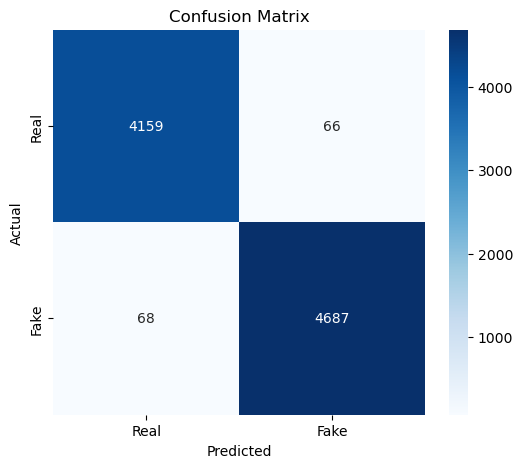

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

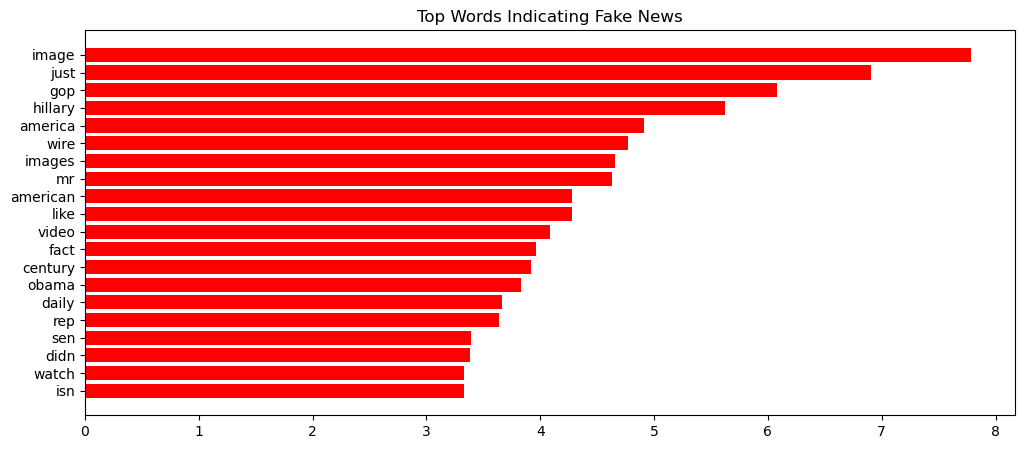

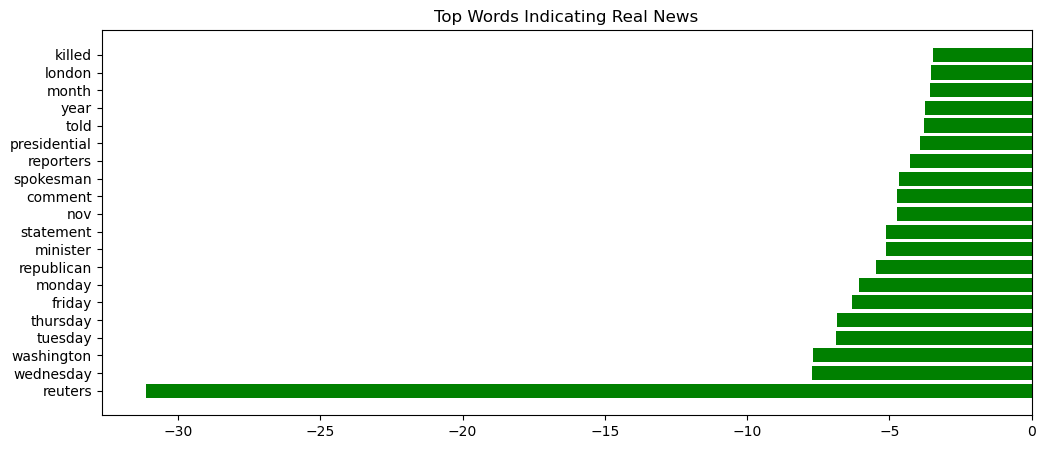

In [18]:
#  🔹 Feature Importance (Top Words)
feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = model.coef_[0]

top_fake_idx = np.argsort(coefficients)[-20:]
top_fake_words = feature_names[top_fake_idx]
top_fake_values = coefficients[top_fake_idx]

top_real_idx = np.argsort(coefficients)[:20]
top_real_words = feature_names[top_real_idx]
top_real_values = coefficients[top_real_idx]

plt.figure(figsize=(12,5))
plt.barh(top_fake_words, top_fake_values, color='red')
plt.title("Top Words Indicating Fake News")
plt.show()

plt.figure(figsize=(12,5))
plt.barh(top_real_words, top_real_values, color='green')
plt.title("Top Words Indicating Real News")
plt.show()

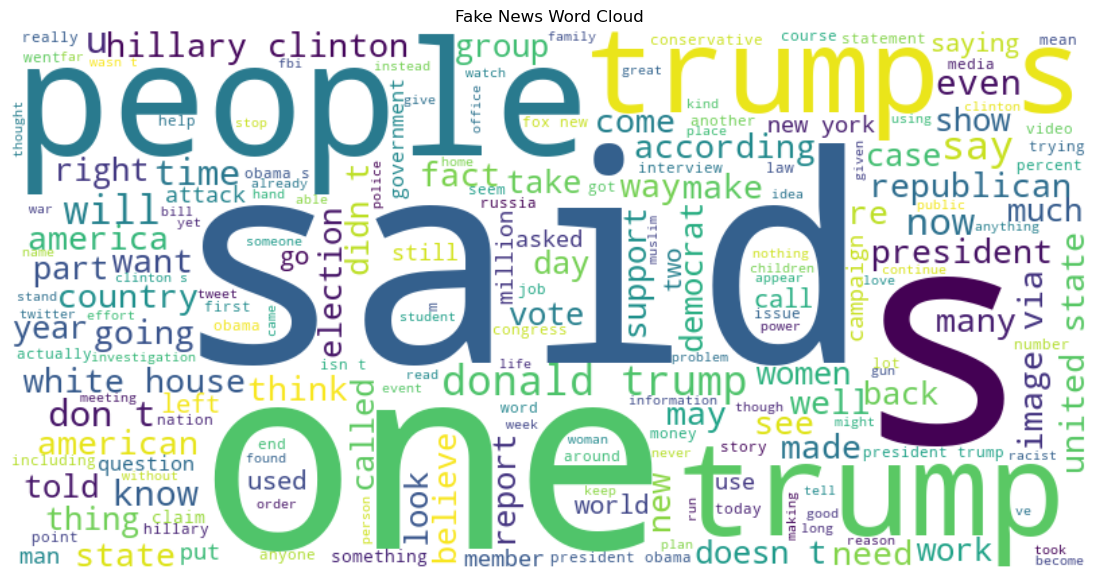

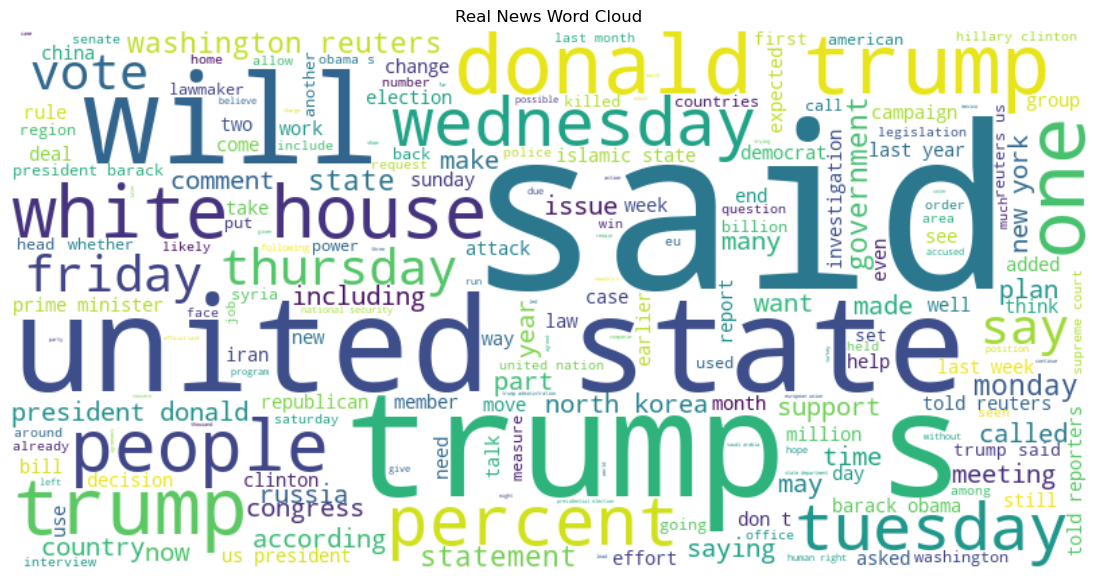

In [19]:
# 🔹 Word Clouds
fake_text = " ".join(df[df['label']==1]['text'])
fake_wc = WordCloud(width=800, height=400, background_color='white').generate(fake_text)
plt.figure(figsize=(15,7))
plt.imshow(fake_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Fake News Word Cloud")
plt.show()

real_text = " ".join(df[df['label']==0]['text'])
real_wc = WordCloud(width=800, height=400, background_color='white').generate(real_text)
plt.figure(figsize=(15,7))
plt.imshow(real_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Real News Word Cloud")
plt.show()


In [20]:
# ===== ENSURE ALL REQUIRED VARIABLES EXIST =====

# Train-test split (if not already done)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = model.predict(X_test_tfidf)
y_prob = model.predict_proba(X_test_tfidf)[:, 1]

# Feature importance
import numpy as np
feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = model.coef_[0]

print("✅ All variables created successfully")


✅ All variables created successfully


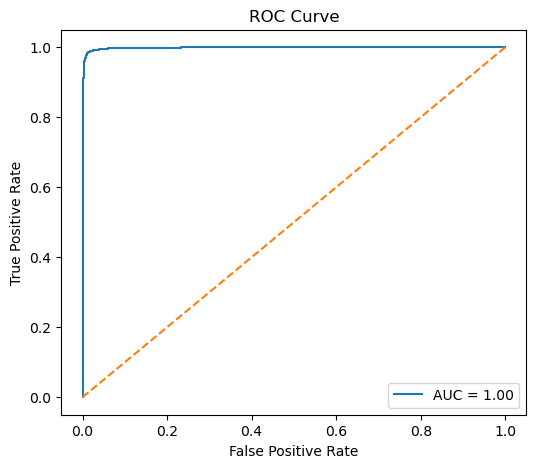

In [21]:
# ROC Curve (Very Important)



from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test_tfidf)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

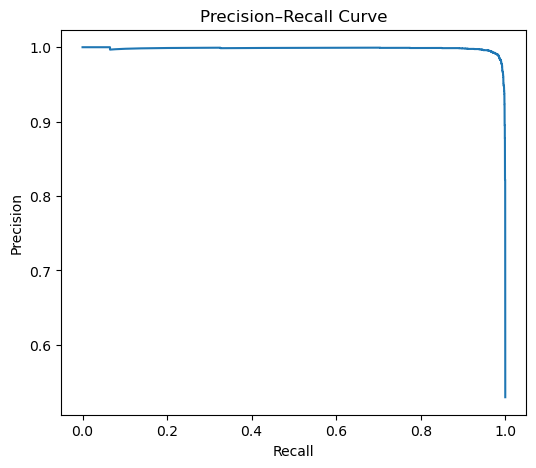

In [22]:
# Precision–Recall Curve



from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()

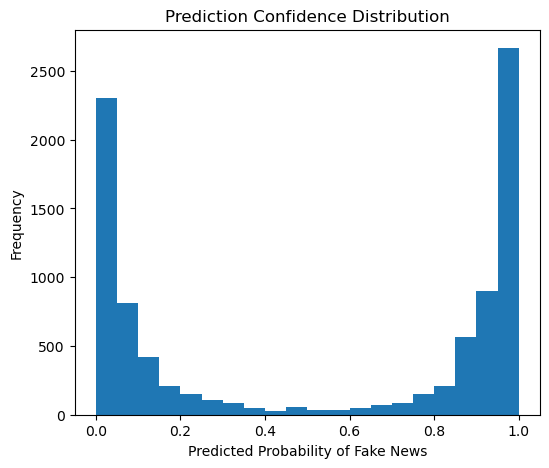

In [23]:
# Prediction Confidence Distribution



plt.figure(figsize=(6,5))
plt.hist(y_prob, bins=20)
plt.xlabel("Predicted Probability of Fake News")
plt.ylabel("Frequency")
plt.title("Prediction Confidence Distribution")
plt.show()

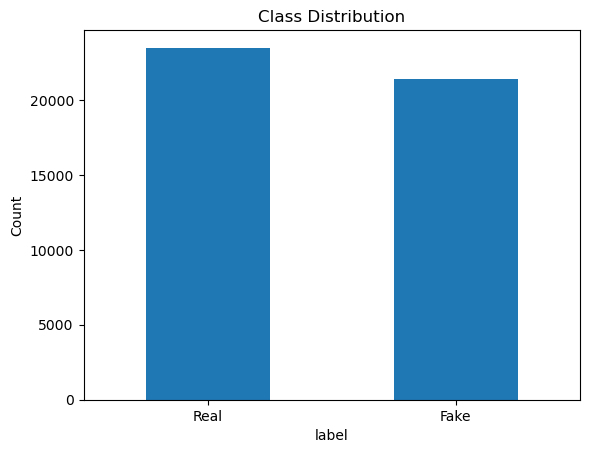

In [24]:
# Class Distribution Bar Chart.

df["label"].value_counts().plot(kind="bar")
plt.xticks([0,1], ["Real", "Fake"], rotation=0)
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

In [25]:
# 🔹 Prediction Probabilities Example
def predict_news(news):
    news = clean_text(news)
    vect = vectorizer.transform([news])
    prob = model.predict_proba(vect)[0]
    pred = model.predict(vect)[0]
    print(f"Prediction: {'Fake News 🚨' if pred==1 else 'Real News ✅'}")
    print(f"Confidence - Real: {prob[0]*100:.2f}%, Fake: {prob[1]*100:.2f}%")
    return pred, prob

sample_news = "" 

predict_news(sample_news)


Prediction: Fake News 🚨
Confidence - Real: 12.97%, Fake: 87.03%


(np.int64(1), array([0.12972771, 0.87027229]))